In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('aqi.csv')

In [7]:
df.isna().values.any()

np.True_

In [10]:
#drop the columns with null
df=df.drop(columns=['note'])
df

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...
...,...,...,...,...,...,...,...,...
235780,01-04-2022,Bihar,Arrah,1,PM10,210,Poor,number_of_monitoring_stations in Absolute Numb...
235781,01-04-2022,Rajasthan,Jaipur,3,"PM2.5,PM10",158,Moderate,number_of_monitoring_stations in Absolute Numb...
235782,01-04-2022,Maharashtra,Chandrapur,2,PM2.5,201,Poor,number_of_monitoring_stations in Absolute Numb...
235783,01-04-2022,Uttar Pradesh,Varanasi,4,PM10,128,Moderate,number_of_monitoring_stations in Absolute Numb...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 8 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   date                           235785 non-null  object
 1   state                          235785 non-null  object
 2   area                           235785 non-null  object
 3   number_of_monitoring_stations  235785 non-null  int64 
 4   prominent_pollutants           235785 non-null  object
 5   aqi_value                      235785 non-null  int64 
 6   air_quality_status             235785 non-null  object
 7   unit                           235785 non-null  object
dtypes: int64(2), object(6)
memory usage: 14.4+ MB


In [12]:
#convert date to datetime
df['date']=pd.to_datetime(df['date'],format='%d-%m-%Y')
df.dtypes

,0
date,datetime64[ns]
state,object
area,object
number_of_monitoring_stations,int64
prominent_pollutants,object
aqi_value,int64
air_quality_status,object
unit,object


In [15]:
print(df['aqi_value'].max())
print(df['aqi_value'].min())

500
3


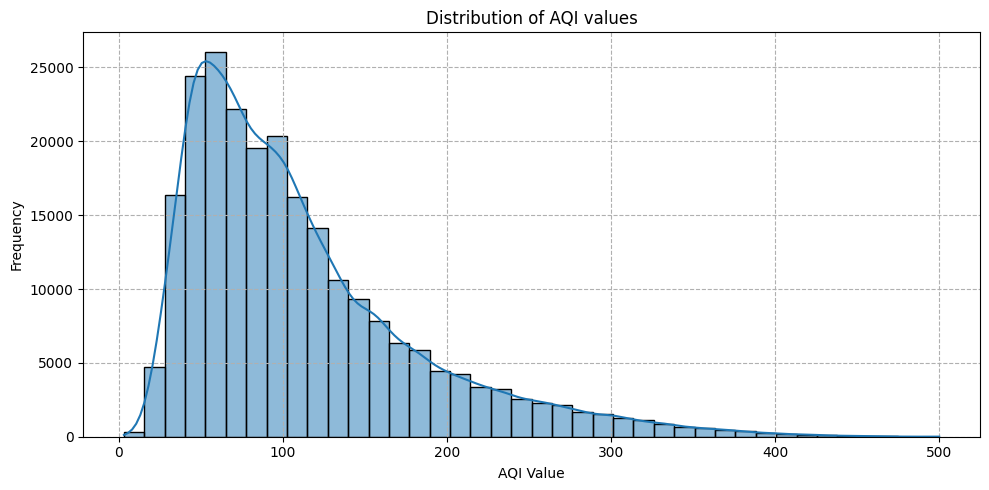

In [28]:
#distribution of aqi values

plt.figure(figsize=(10,5))
sns.histplot(data=df,x='aqi_value',bins=40,kde=True)
plt.title('Distribution of AQI values')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.grid(True,linestyle='--')
plt.tight_layout()
plt.show()

/tmp/ipython-input-913901167.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='air_quality_status',palette='viridis')


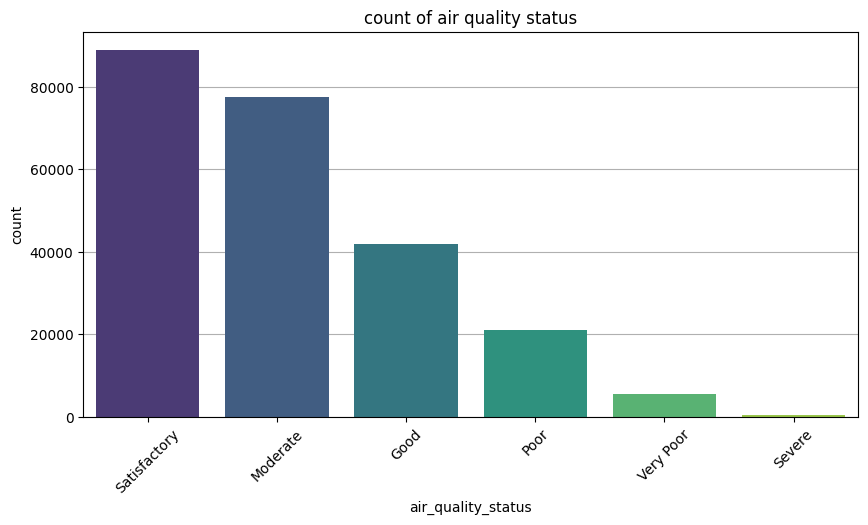

In [29]:
#aqi status
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='air_quality_status',palette='viridis')
plt.title('count of air quality status')
plt.gca().set_axisbelow(True)
plt.grid(True,axis='y')
plt.xticks(rotation=45)
plt.show()

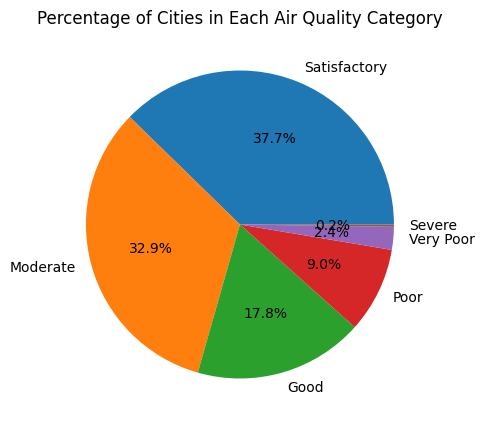

In [31]:
category_counts=df['air_quality_status'].value_counts(normalize=True)*100
plt.figure(figsize=(10,5))
plt.pie(category_counts,labels=category_counts.index,autopct='%1.1f%%')
plt.title("Percentage of Cities in Each Air Quality Category")
plt.show()

In [33]:
#group by state
state_aqi_stats=df.groupby('state')['aqi_value'].agg(['mean','max'])
print(state_aqi_stats)

                                   mean  max
state                                       
Andaman and Nicobar Islands   57.706897  150
Andhra Pradesh                77.507701  500
Arunachal Pradesh             54.485265  183
Assam                        114.117456  442
Bihar                        157.158122  488
Chandigarh                   141.561778  412
Chhattisgarh                  78.986321  345
Delhi                        206.416889  494
Gujarat                      110.634272  384
Haryana                      140.852806  469
Himachal Pradesh             160.257036  438
Jammu and Kashmir             69.495434  251
Jharkhand                    164.940361  436
Karnataka                     62.672853  500
Kerala                        68.070147  293
Madhya Pradesh               108.716483  500
Maharashtra                  103.639833  460
Manipur                      100.927361  500
Meghalaya                     62.731121  484
Mizoram                       47.247000  183
Nagaland  

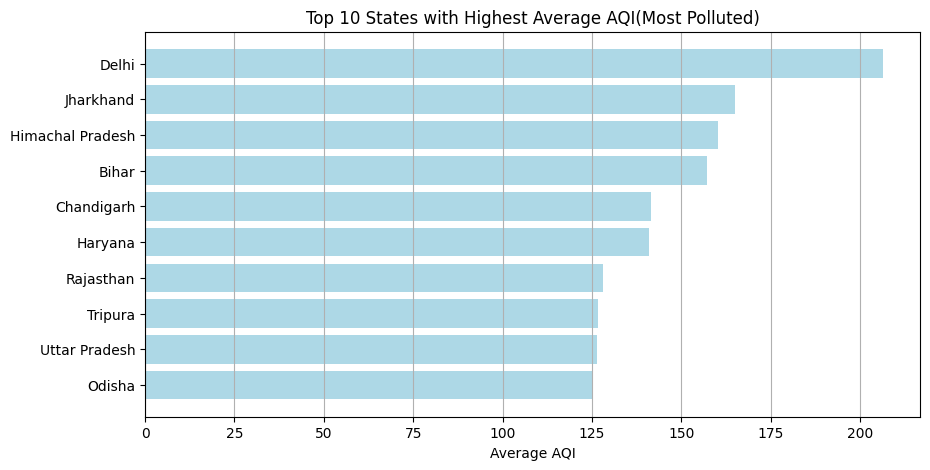

In [36]:
#top 10 states

avg_aqi=df.groupby('state')['aqi_value'].mean()
top10=avg_aqi.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.barh(top10.index,top10.values,color='lightblue')
plt.xlabel("Average AQI")
plt.title("Top 10 States with Highest Average AQI(Most Polluted)")
plt.gca().invert_yaxis()
plt.grid(True,axis='x')
plt.show()

In [38]:
area_aqi_stats = df.groupby('area')['aqi_value'].agg(['mean', 'max', 'min']).sort_values('mean', ascending=False)
print(area_aqi_stats.head(10))   # top polluted
print(area_aqi_stats.tail(10))   # cleanest



                      mean  max  min
area                                
Byrnihat        239.995427  442   36
Begusarai       206.680412  474   27
Delhi           206.416889  494   44
Greater Noida   201.601959  494   23
Sri Ganganagar  197.939351  441   43
Gurugram        190.848214  469   29
Darbhanga       190.089844  473   26
Dharuhera       185.722513  447   34
NOIDA           183.989324  456   32
Ghaziabad       183.010676  438   14
                     mean  max  min
area                               
Silchar         47.476510   89    3
Chikkamagaluru  47.455710  132   18
Aizawl          47.247000  183    7
Ernakulam       46.939394  118   23
Bagalkot        46.456585   96   31
Thanjavur       44.722222  140   22
Palkalaiperur   43.325000  103   11
Chamarajanagar  43.058605   96   29
Madikeri        37.807910  159   10
Tirunelveli     32.110132   49   18


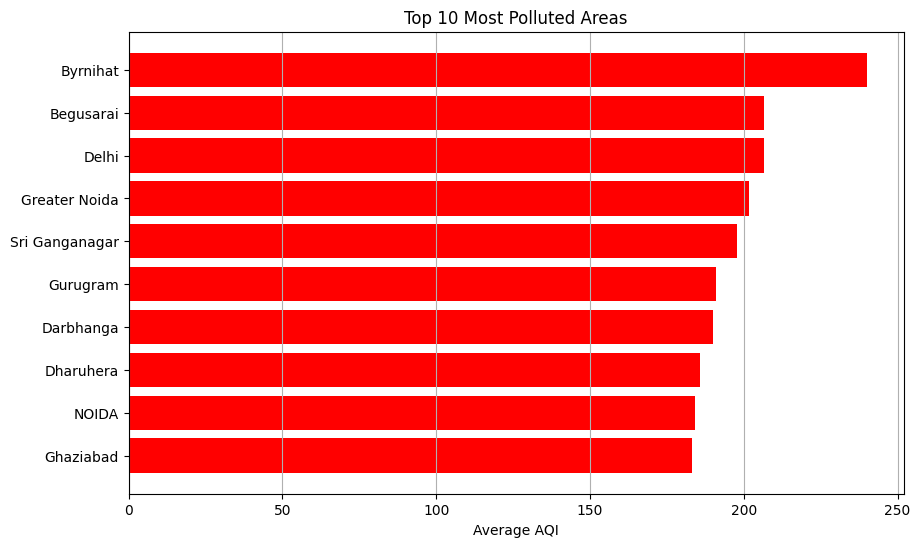

In [39]:
#polluted top 10
top10 = df.groupby('area')['aqi_value'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10.index, top10.values, color='red')
plt.xlabel("Average AQI")
plt.title("Top 10 Most Polluted Areas")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()


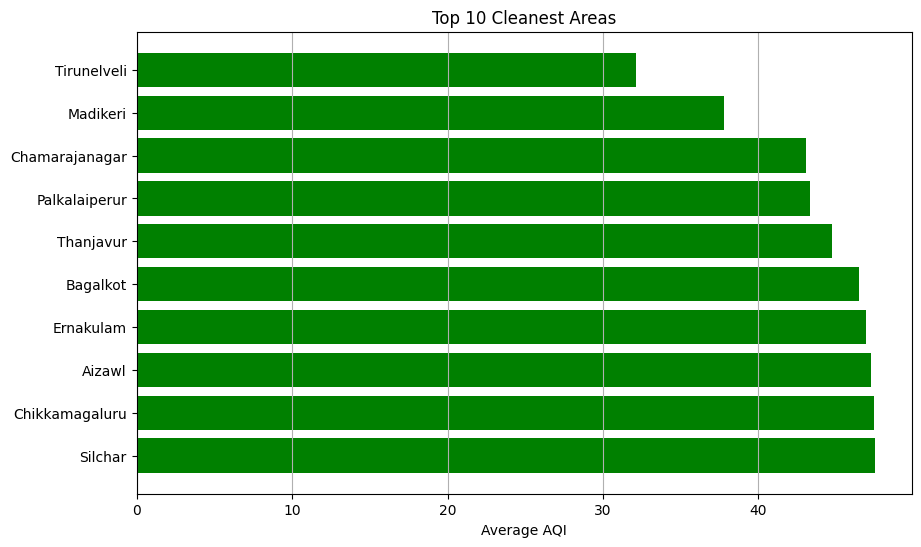

In [40]:
#Cleanest top 10
clean10 = df.groupby('area')['aqi_value'].mean().sort_values().head(10)

plt.figure(figsize=(10,6))
plt.barh(clean10.index, clean10.values, color='green')
plt.xlabel("Average AQI")
plt.title("Top 10 Cleanest Areas")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()


In [41]:
#pollutant which contributes to high AQI

pollutant_impact = df.groupby('prominent_pollutants')['aqi_value'].mean().sort_values(ascending=False)
print(pollutant_impact)


prominent_pollutants
PM2.5                167.844696
PM2.5,PM10           129.880521
O3,PM2.5,PM10        119.869480
PM2.5,O3             117.540709
PM2.5,NO2            110.077108
PM10,NO2,PM2.5,O3    106.372093
PM10,O3               96.741185
PM10                  93.674300
PM2.5,SO2             93.622302
PM10,PM2.5,NO2        89.825623
O3                    89.748735
NO2                   78.918659
PM10,NO2,O3           78.555556
NO2,SO2               73.294118
PM2.5,PM10,CO         72.291549
PM10,NO2              72.202660
NO2,O3                72.122302
PM2.5,NH3,O3          70.000000
PM10,NH3,O3           65.500000
CO,O3                 64.753223
CO                    63.617704
PM10,CO               61.970278
PM10,O3,CO            61.906699
CO,NO2                61.762774
PM2.5,CO,O3           59.424242
PM10,PM2.5,SO2        59.369369
SO2,O3                58.119266
PM10,NH3,CO           58.000000
O3,NH3                55.000000
NO2,PM10,CO           54.507853
PM10,SO2           

In [42]:
pollutant_peak = df.groupby('prominent_pollutants')['aqi_value'].max().sort_values(ascending=False)
print(pollutant_peak)


prominent_pollutants
PM10                 500
PM2.5                500
PM2.5,PM10           468
NO2                  436
O3                   346
PM2.5,O3             324
O3,PM2.5,PM10        315
PM10,O3              306
PM2.5,SO2            301
PM2.5,NO2            281
PM10,NO2             271
PM10,PM2.5,NO2       264
NO2,SO2              236
PM2.5,PM10,CO        227
PM10,NO2,PM2.5,O3    209
CO                   200
SO2                  193
PM10,CO              189
PM10,NO2,O3          188
NO2,O3               186
CO,O3                182
PM10,SO2             161
PM10,PM2.5,SO2       154
PM2.5,CO,O3          150
PM10,O3,CO           149
CO,NO2               148
NO2,PM10,CO          147
PM10,SO2,O3          140
SO2,O3               138
PM2.5,SO2,O3         111
NH3                  107
PM2.5,CO,NO2         101
PM10,CO,SO2           99
NO2,CO,O3             97
PM10,NH3,O3           94
CO,SO2                88
PM2.5,CO,SO2          88
SO3,CO,O3             80
PM2.5,NH3             74
PM2.

In [44]:
df['main_pollutant'] = df['prominent_pollutants'].str.split(',').str[0].str.strip()


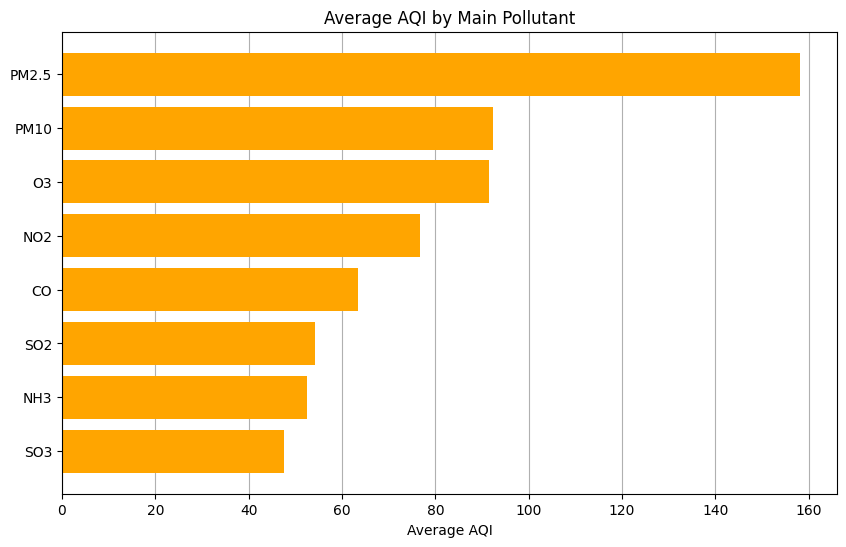

In [45]:
avg = df.groupby('main_pollutant')['aqi_value'].mean().sort_values()

plt.figure(figsize=(10,6))
plt.barh(avg.index, avg.values, color='orange')
plt.xlabel("Average AQI")
plt.title("Average AQI by Main Pollutant")
plt.grid(True, axis='x')
plt.gca().set_axisbelow(True)
plt.show()


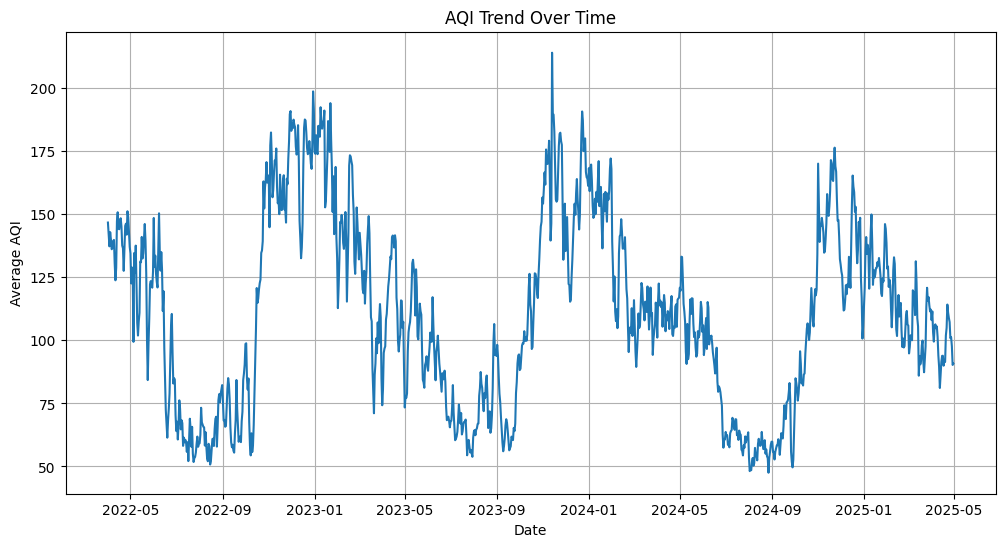

In [46]:
#AQI trends over years

# Calculate daily average AQI
daily_trend = df.groupby('date')['aqi_value'].mean()

# Plot AQI trend
plt.figure(figsize=(12,6))
plt.plot(daily_trend.index, daily_trend.values)
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.title("AQI Trend Over Time")
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.show()


In [49]:
#using prophet for forecasting

ts=df.groupby('date')['aqi_value'].mean().reset_index()
ts=ts.rename(columns={'date':'ds','aqi_value':'y'})
ts.head()

,ds,y
0,2022-04-01,146.691275
1,2022-04-02,141.986842
2,2022-04-03,137.255034
3,2022-04-04,142.877551
4,2022-04-05,139.968354


In [55]:
from prophet import Prophet
# Load and prepare
ts = df.groupby('date')['aqi_value'].mean().reset_index()
ts = ts.rename(columns={'date':'ds','aqi_value':'y'})

# 1) Ensure datetime
ts['ds'] = pd.to_datetime(ts['ds'], dayfirst=True)

# 2) Ensure numeric
ts['y'] = pd.to_numeric(ts['y'], errors='coerce')

# 3) Force DAILY frequency (critical fix)
ts = ts.set_index('ds').asfreq('D').reset_index()

# 4) Drop missing values after frequency reset
ts = ts.dropna()

# 5) Fit model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(ts)

# 6) Make future dataframe
future = model.make_future_dataframe(periods=90)

# 7) Forecast
forecast = model.predict(future)

# Show forecast tail
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,ds,yhat,yhat_lower,yhat_upper
1210,2025-07-25,34.337901,16.776791,52.518069
1211,2025-07-26,34.496095,16.069712,51.723717
1212,2025-07-27,33.576826,16.400495,51.525590
1213,2025-07-28,32.386369,14.639406,49.309756
1214,2025-07-29,33.791455,15.042381,51.711773


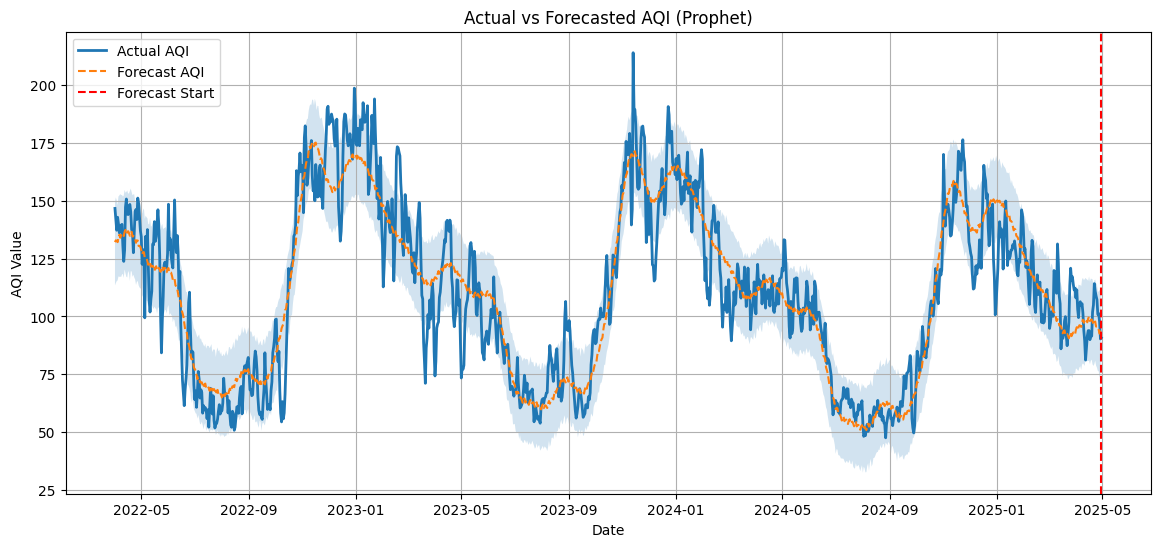

In [56]:
merged = ts.merge(forecast[['ds','yhat','yhat_lower','yhat_upper']], on='ds', how='left')

plt.figure(figsize=(14,6))

# Actual values
plt.plot(merged['ds'], merged['y'], label='Actual AQI', linewidth=2)

# Forecast values
plt.plot(merged['ds'], merged['yhat'], label='Forecast AQI', linestyle='--')

# Confidence interval
plt.fill_between(merged['ds'], merged['yhat_lower'], merged['yhat_upper'], alpha=0.2)

plt.axvline(ts['ds'].max(), color='red', linestyle='--', label='Forecast Start')

plt.xlabel("Date")
plt.ylabel("AQI Value")
plt.title("Actual vs Forecasted AQI (Prophet)")
plt.legend()
plt.grid(True)
plt.show()


In [57]:
train = ts[:-90]
test = ts[-90:]

model = Prophet()
model.fit(train)

test_pred = model.predict(test[['ds']])

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(test['y'], test_pred['yhat'])

print("MAE:", mae)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


MAE: 18.324690567467982


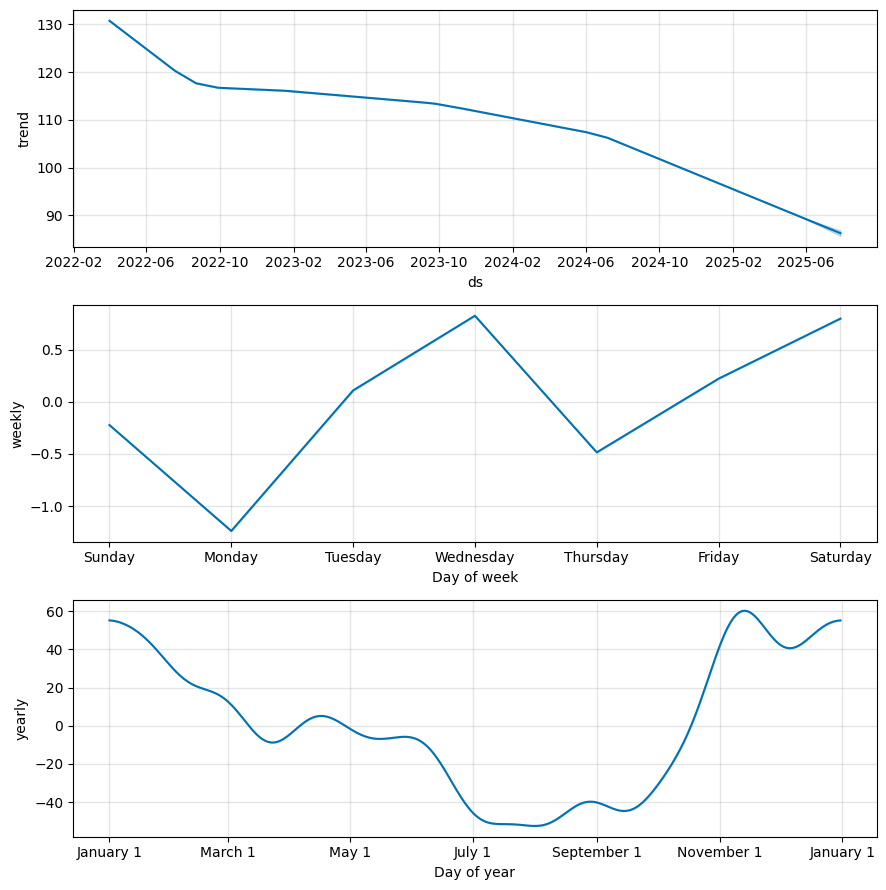

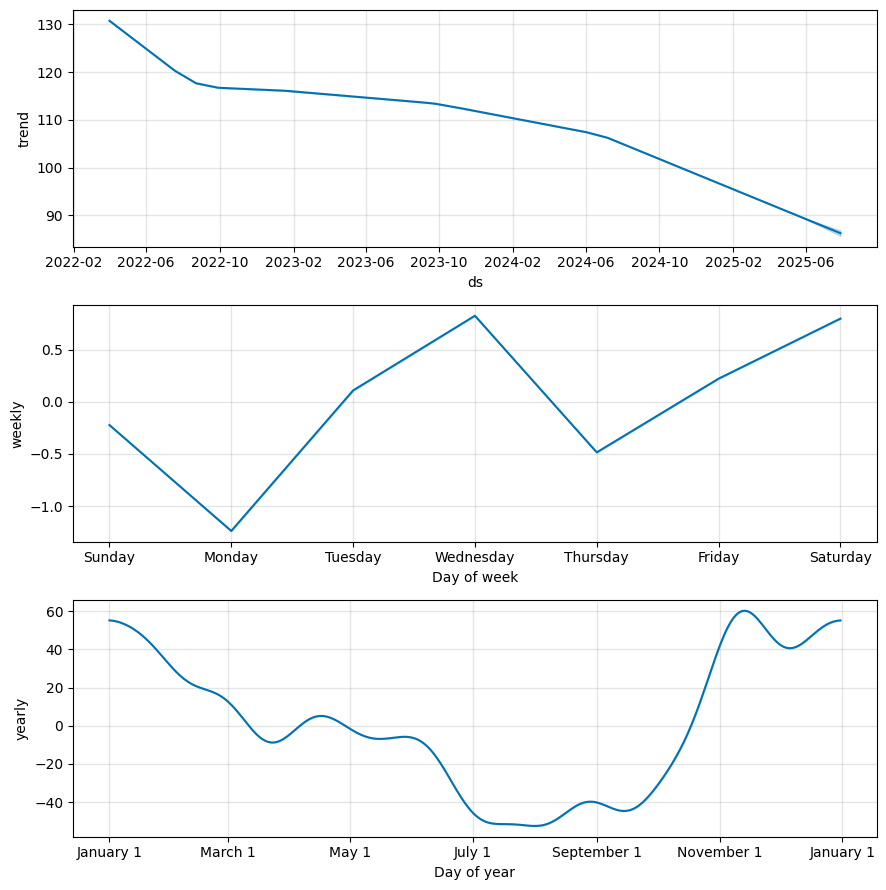

In [58]:
model.plot_components(forecast)
